In [12]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [13]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_rows_cleaned1.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_cleaned1.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
0                         0.0            160.00  1941     12    1     0   
1                         0.0            160.

In [14]:
# remove rows where HourlyVisibility is zero or missing
CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
#CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

print("CV_rows:", CV_rows.shape)

CV_rows: (10739952, 12)


In [15]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 200.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10373906, 12)


In [16]:
#counting days measured per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        97
1  BAKERSFIELD AP  1929       269
2  BAKERSFIELD AP  1930        97
3  BAKERSFIELD AP  1931       254
4  BAKERSFIELD AP  1932       366


In [17]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


In [18]:
station_year_counts = (
    CV_rows
    .drop_duplicates(subset=['STATION', 'year'])
    .groupby('STATION')['year']
    .nunique()
    .sort_values(ascending=False)
)

stations_30_years = station_year_counts[station_year_counts > 30].index.tolist()
stations_30_years_pre1970 = [s for s in stations_30_years if s in stations_pre1970]

print(len(stations_30_years), "stations with more than 30 years of data")
print("stations_30_years_pre1970:", stations_30_years_pre1970)
station_year_counts.loc[stations_30_years_pre1970]

14 stations with more than 30 years of data
stations_30_years_pre1970: ['BAKERSFIELD AP', 'SACRAMENTO AP ASOS', 'RED BLUFF MUNI AP', 'FRESNO YOSEMITE INTL', 'SACRAMENTO MATHER AFB', 'TRAVIS FIELD AFB', 'STOCKTON AP', 'SACRAMENTO MCCLELLAN AFB', 'CASTLE AFB', 'LEMOORE REEVES NAS', 'BEALE AFB', 'REDDING AP']


STATION
BAKERSFIELD AP              99
SACRAMENTO AP ASOS          96
RED BLUFF MUNI AP           86
FRESNO YOSEMITE INTL        83
SACRAMENTO MATHER AFB       78
TRAVIS FIELD AFB            78
STOCKTON AP                 76
SACRAMENTO MCCLELLAN AFB    73
CASTLE AFB                  67
LEMOORE REEVES NAS          66
BEALE AFB                   62
REDDING AP                  55
Name: year, dtype: int64

In [19]:
# Remove stations with 200 or fewer days counted
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] > 355].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_fog_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 1005
CV_fog_rows_no_outliers: (9353349, 12)


In [20]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]
# low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]

print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)
# low_vis_rows.head()

CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (187643, 12)


In [ ]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [25]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (810, 3)


In [26]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
if low_vis_events["DATE"].dtype == object:
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=1.5)
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

event_summary = (
    low_vis_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "min"),
        end=("DATE", "max"),
        year=("year", "first"),
        month=("month", "first"),
        duration_hours=("event_id", "size"),
    )
)

event_summary["year_month"] = pd.to_datetime(
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

monthly_low_vis_days = (
    low_vis_events
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "low_vis_days"})
)

event_monthly = (
    event_summary
    .groupby(["STATION", "year", "month"], as_index=False)
    .agg(
        avg_event_duration_hours=("duration_hours", "mean"),
        n_events=("duration_hours", "size"),
    )
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

event_monthly["year_month"] = pd.to_datetime(
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

annual_event_stats = (
    event_monthly
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        total_events=("n_events", "sum"),
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

annual_compare = low_vis_fog_days_year.merge(
    annual_event_stats,
    on=["STATION", "year"],
    how="left"
)

print(annual_compare.head())

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932        10                  2.400000            11   
1  BAKERSFIELD AP  1933        18                  2.261973            40   
2  BAKERSFIELD AP  1934        36                  2.530311            63   
3  BAKERSFIELD AP  1935        20                  2.317972            40   
4  BAKERSFIELD AP  1936        14                  2.676768            20   

   avg_monthly_low_vis_days  
0                  3.333333  
1                  6.000000  
2                  7.200000  
3                  5.000000  
4                  2.333333  


C:\Users\Work Account\AppData\Local\Temp\ipykernel_14348\1308038892.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


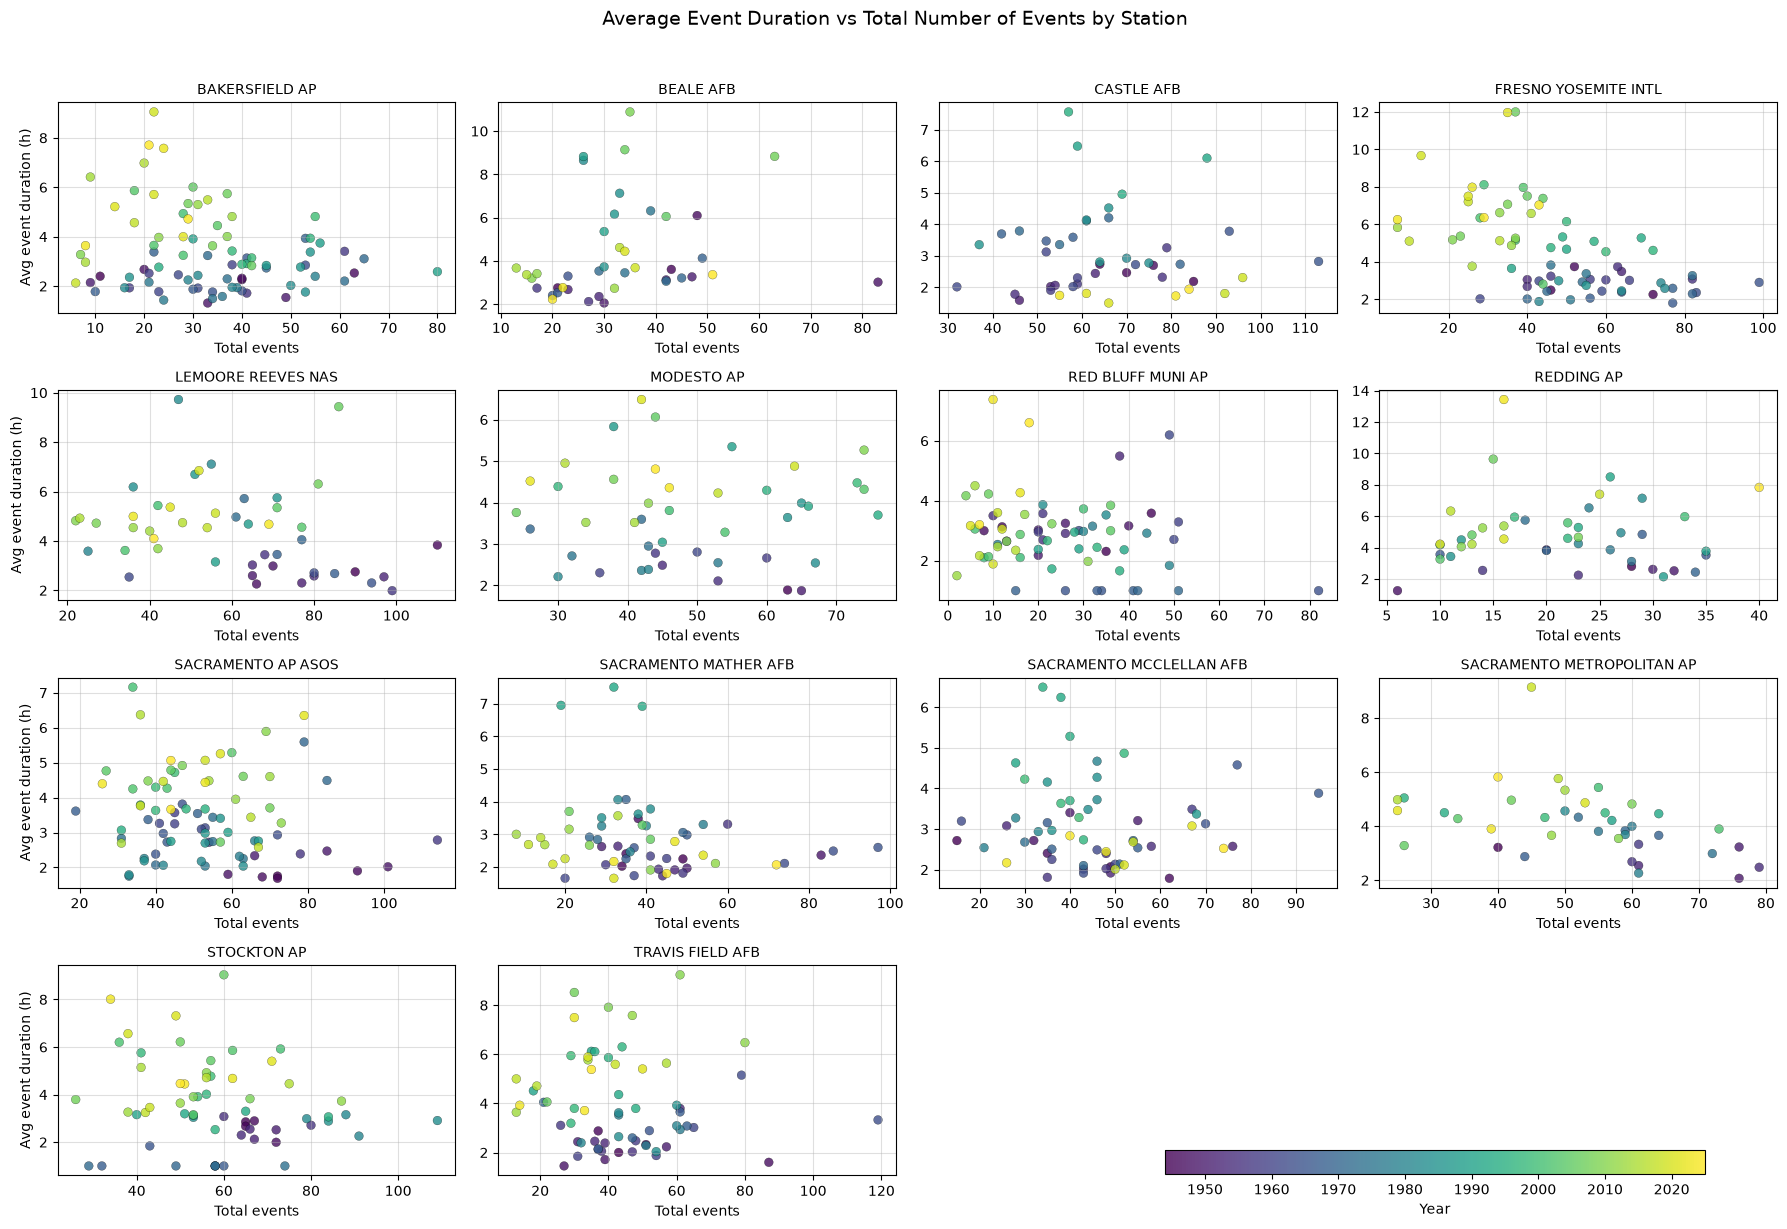

In [27]:
# only using stations with long records
# plot the average event duration vs total number events per station for each year
# each data point is color coded by year
stations = stations_with_30_years.tolist()
plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=False, sharey=False)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    sc = ax.scatter(
        station_df["total_events"],
        station_df["avg_event_duration_hours"],
        c=station_df["year"],
        cmap="viridis",
        s=40,
        alpha=0.8,
        edgecolor="k",
        linewidth=0.2,
    )
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Total events")
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    ax.grid(True, alpha=0.4)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

cax = fig.add_axes([0.65, 0.05, 0.3, 0.02])  # setting color bar [left, bottom, width, height]

cbar = fig.colorbar(sc, cax=cax, orientation="horizontal", fraction=0.02, pad=0.02)
cbar.set_label("Year")

fig.suptitle("Average Event Duration vs Total Number of Events by Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_14348\3362479217.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


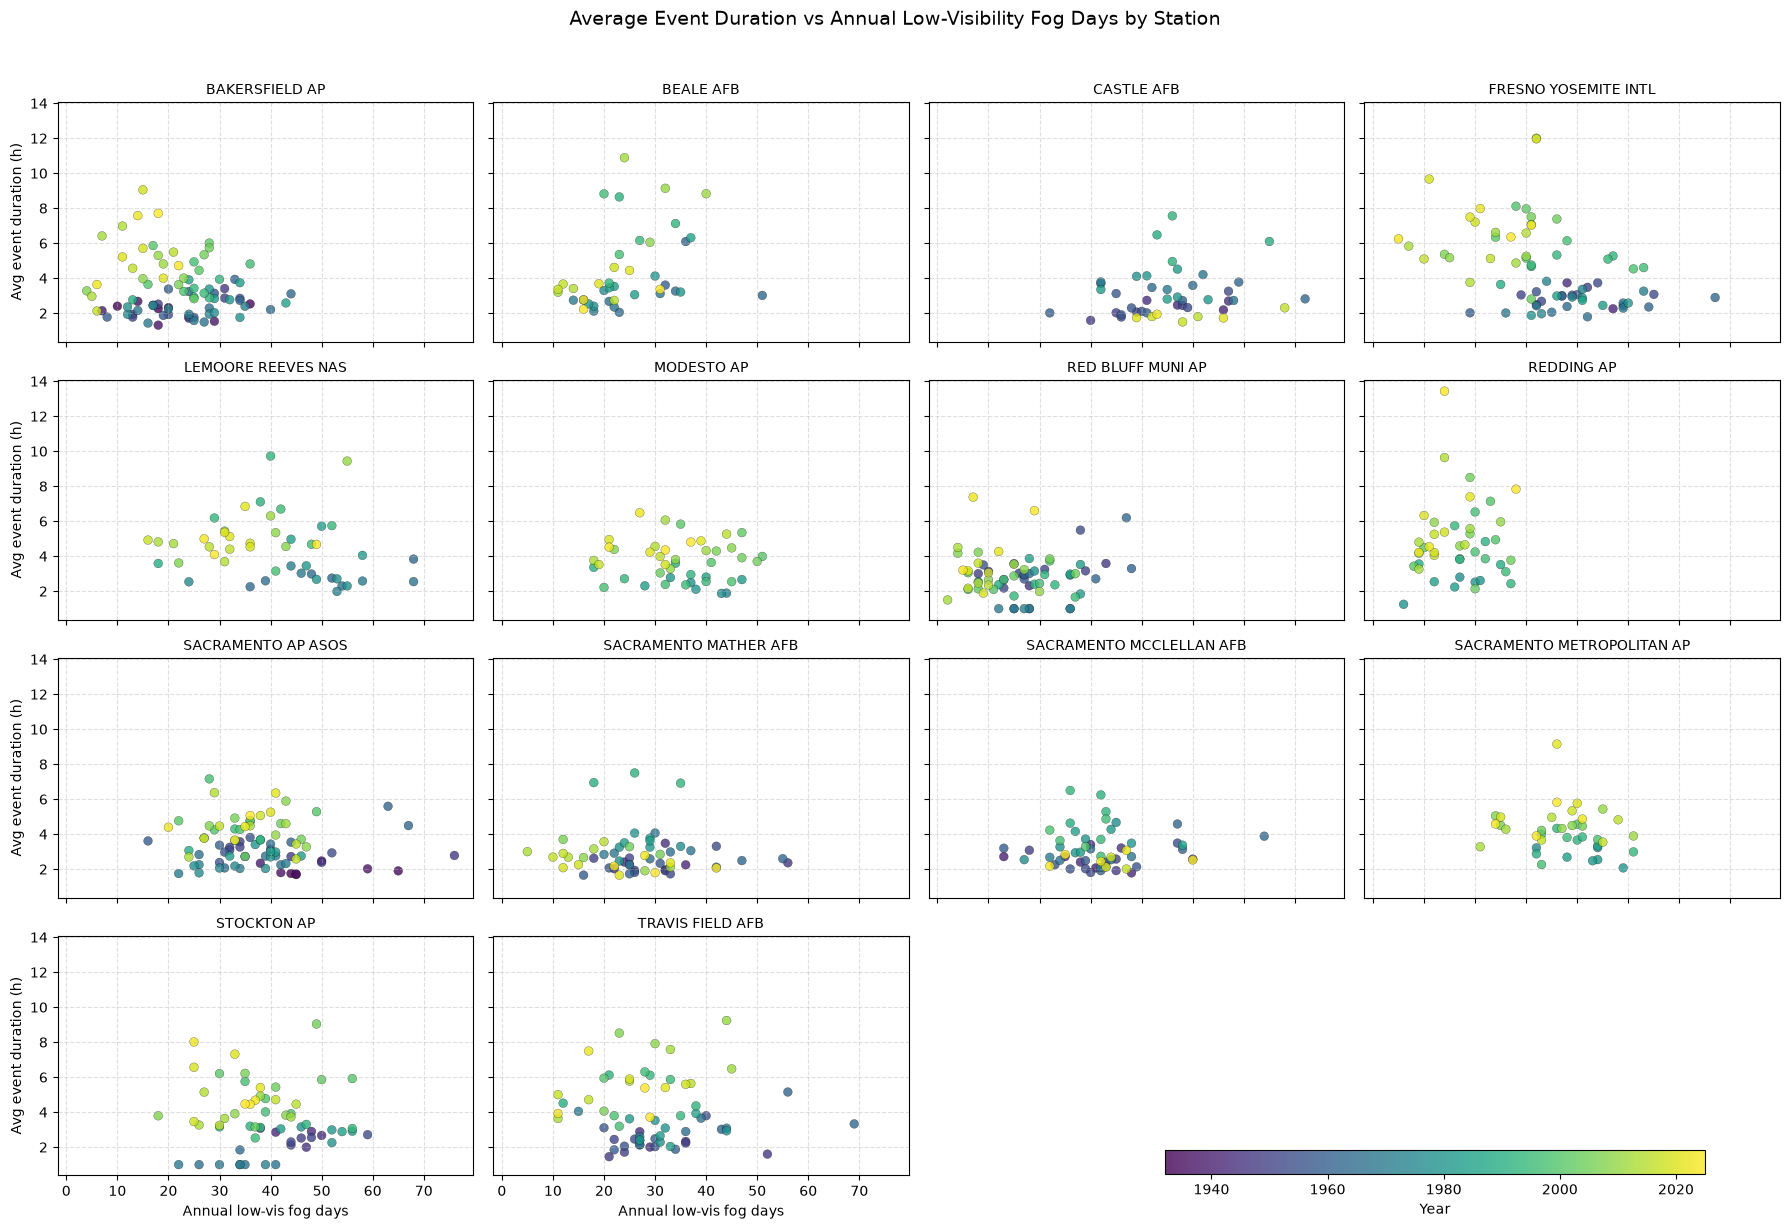

In [29]:
stations = stations_with_30_years.tolist()
plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()

year_min = plot_df["year"].min()
year_max = plot_df["year"].max()
norm = plt.Normalize(year_min, year_max)
cmap = plt.cm.viridis

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

sc = None
for idx, station in enumerate(stations):
    ax = axes[idx]
    station_ann = plot_df[
        (plot_df["STATION"] == station) &
        plot_df["avg_event_duration_hours"].notna()
    ].sort_values("year")

    if station_ann.empty:
        ax.set_visible(False)
        continue

    sc = ax.scatter(
        station_ann["fog_days"],
        station_ann["avg_event_duration_hours"],
        c=station_ann["year"],
        cmap=cmap,
        norm=norm,
        s=40,
        alpha=0.8,
        edgecolor="k",
        linewidth=0.2,
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Annual low-vis fog days")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

if sc is not None:
    cax = fig.add_axes([0.65, 0.05, 0.3, 0.02])  # [left, bottom, width, height]
    cbar = fig.colorbar(sc, cax=cax, orientation="horizontal",fraction=0.02, pad=0.04)
    cbar.set_label("Year")

fig.suptitle("Average Event Duration vs Annual Low-Visibility Fog Days by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

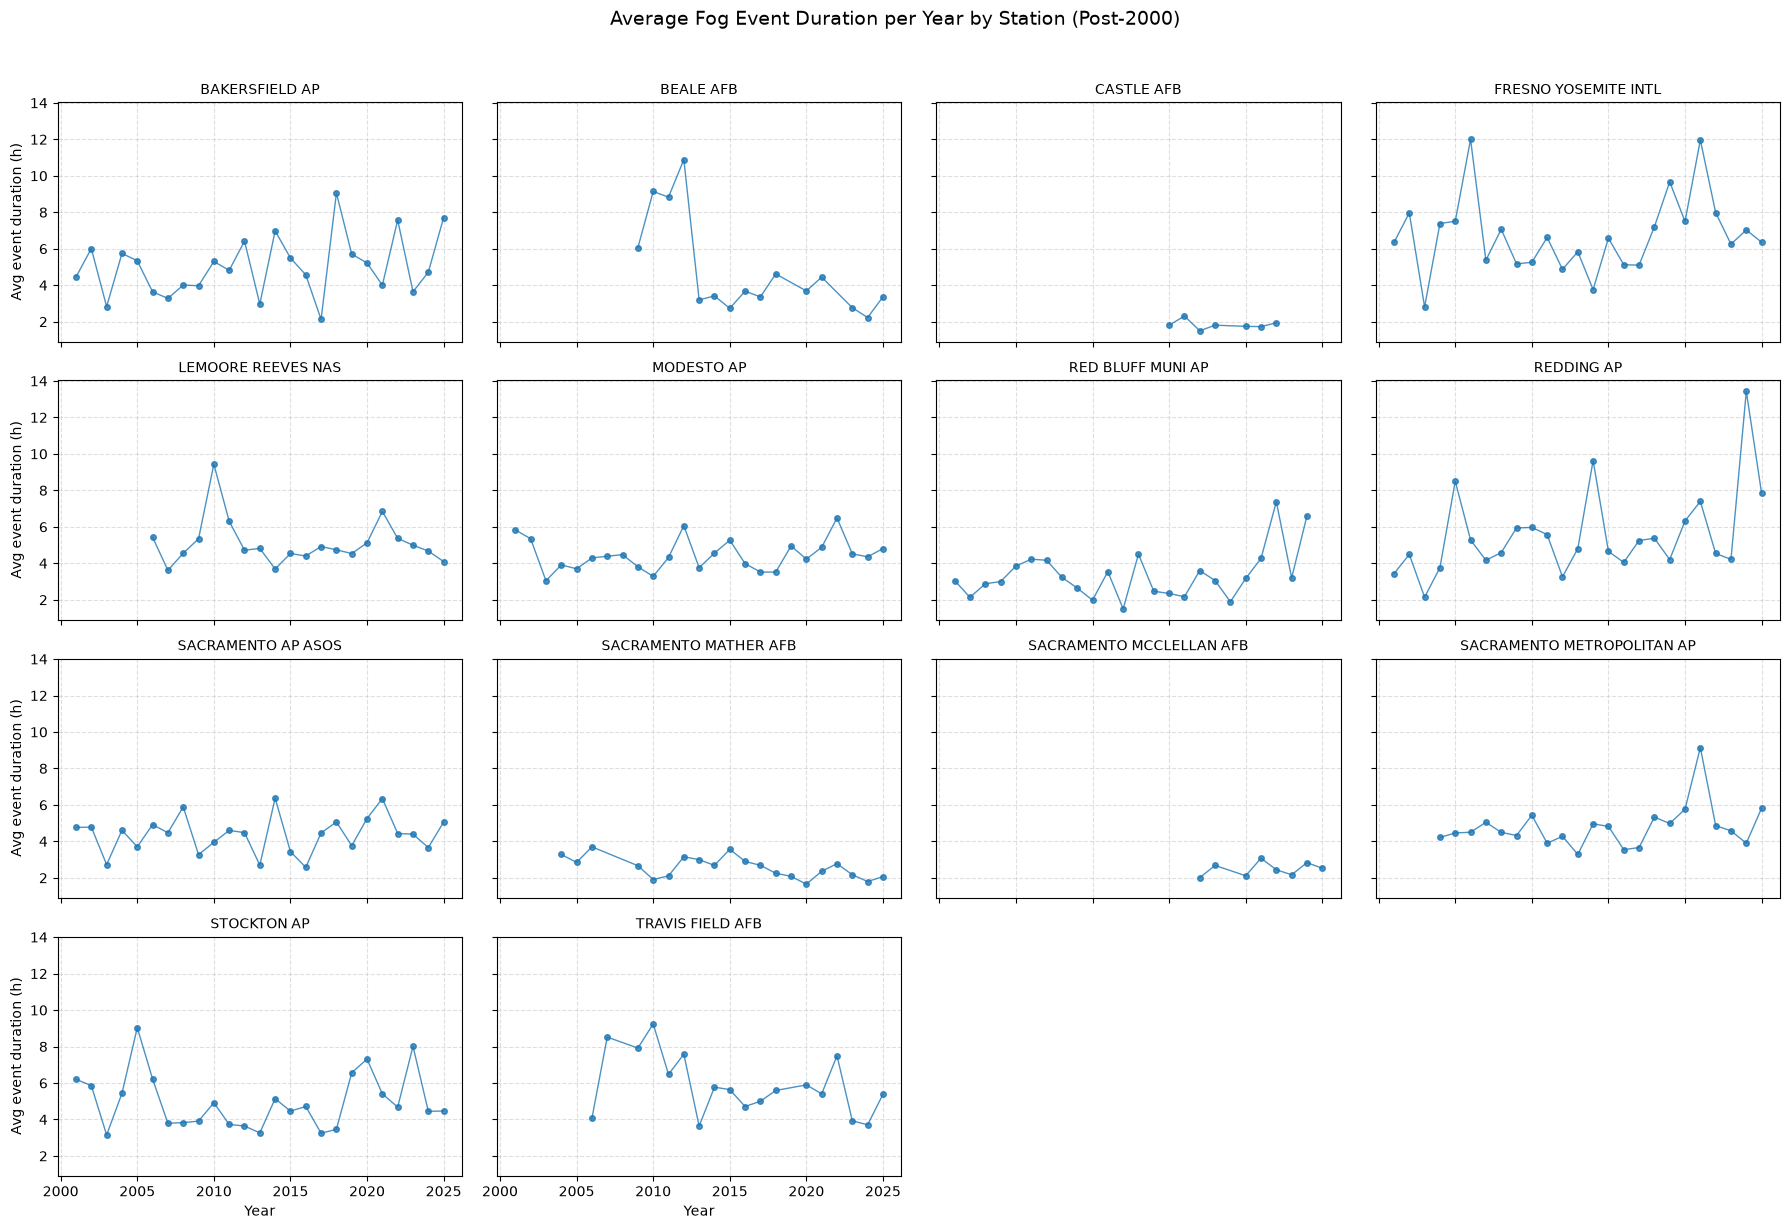

In [30]:
stations = stations_with_30_years.tolist()
plot_df = annual_compare[
    (annual_compare["year"] > 2000) &
    (annual_compare["STATION"].isin(stations))
].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[
        (plot_df["STATION"] == station) &
        (plot_df["avg_event_duration_hours"].notna())
    ].sort_values("year")

    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.plot(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="-",
        markersize=4,
        alpha=0.8,
        linewidth=1
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration per Year by Station (Post-2000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Find stations with continuous data since 2000
stations_continuous_since_2000 = (
    annual_compare[annual_compare["year"] >= 2000]
    .groupby("STATION")["year"]
    .apply(lambda x: (x.max() - x.min() + 1) == len(x))
    .loc[lambda x: x]
    .index.tolist()
)

print(f"Stations with continuous data since 2000: {len(stations_continuous_since_2000)}")
print(stations_continuous_since_2000)

Stations with continuous data since 2000: 14
['BAKERSFIELD AP', 'CHICO ARMY FLYING SCHOOL', 'FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'LIVERMORE MUNICIPAL AP', 'MADERA MUNICIPAL AP', 'MERCED MUNICIPAL AP', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'REEDLEY MUNI', 'SACRAMENTO AP ASOS', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP']


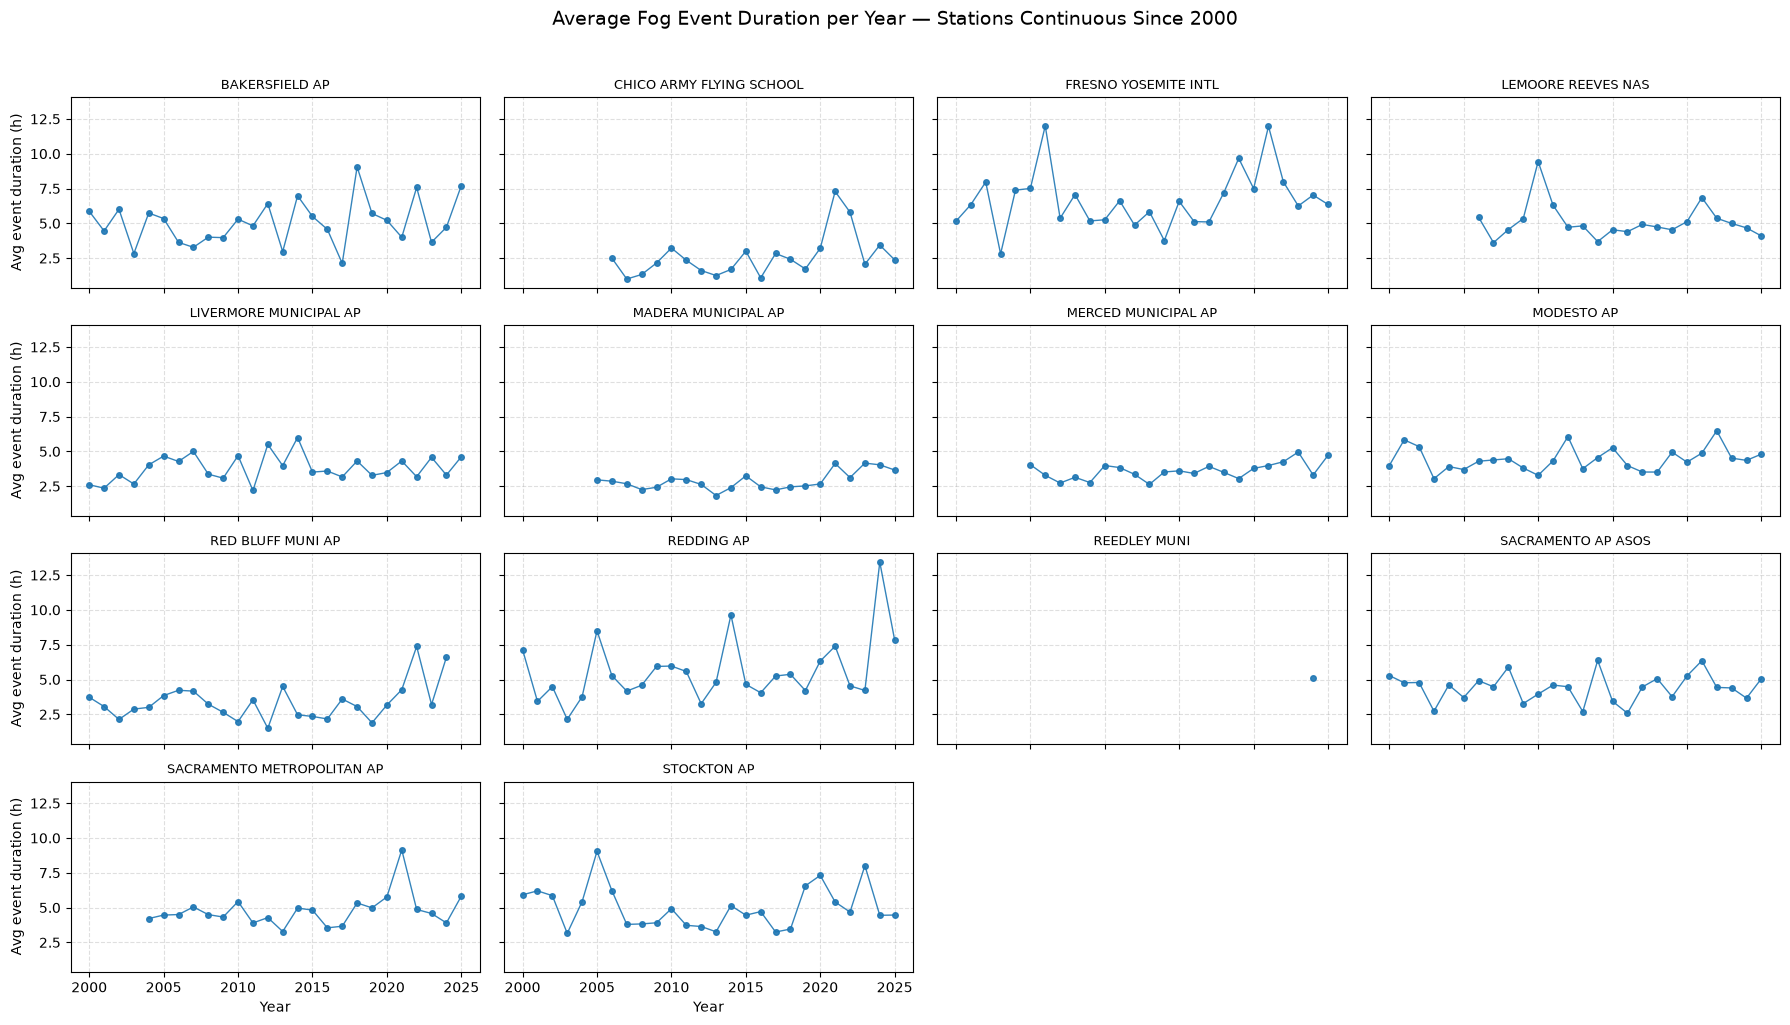

In [32]:
stations = stations_continuous_since_2000
plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()
plot_df = plot_df[plot_df["year"] >= 2000]

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.5), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue
    ax.plot(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="-",
        markersize=4,
        linewidth=1,
        alpha=0.9
    )
    ax.set_title(station, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration per Year — Stations Continuous Since 2000", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

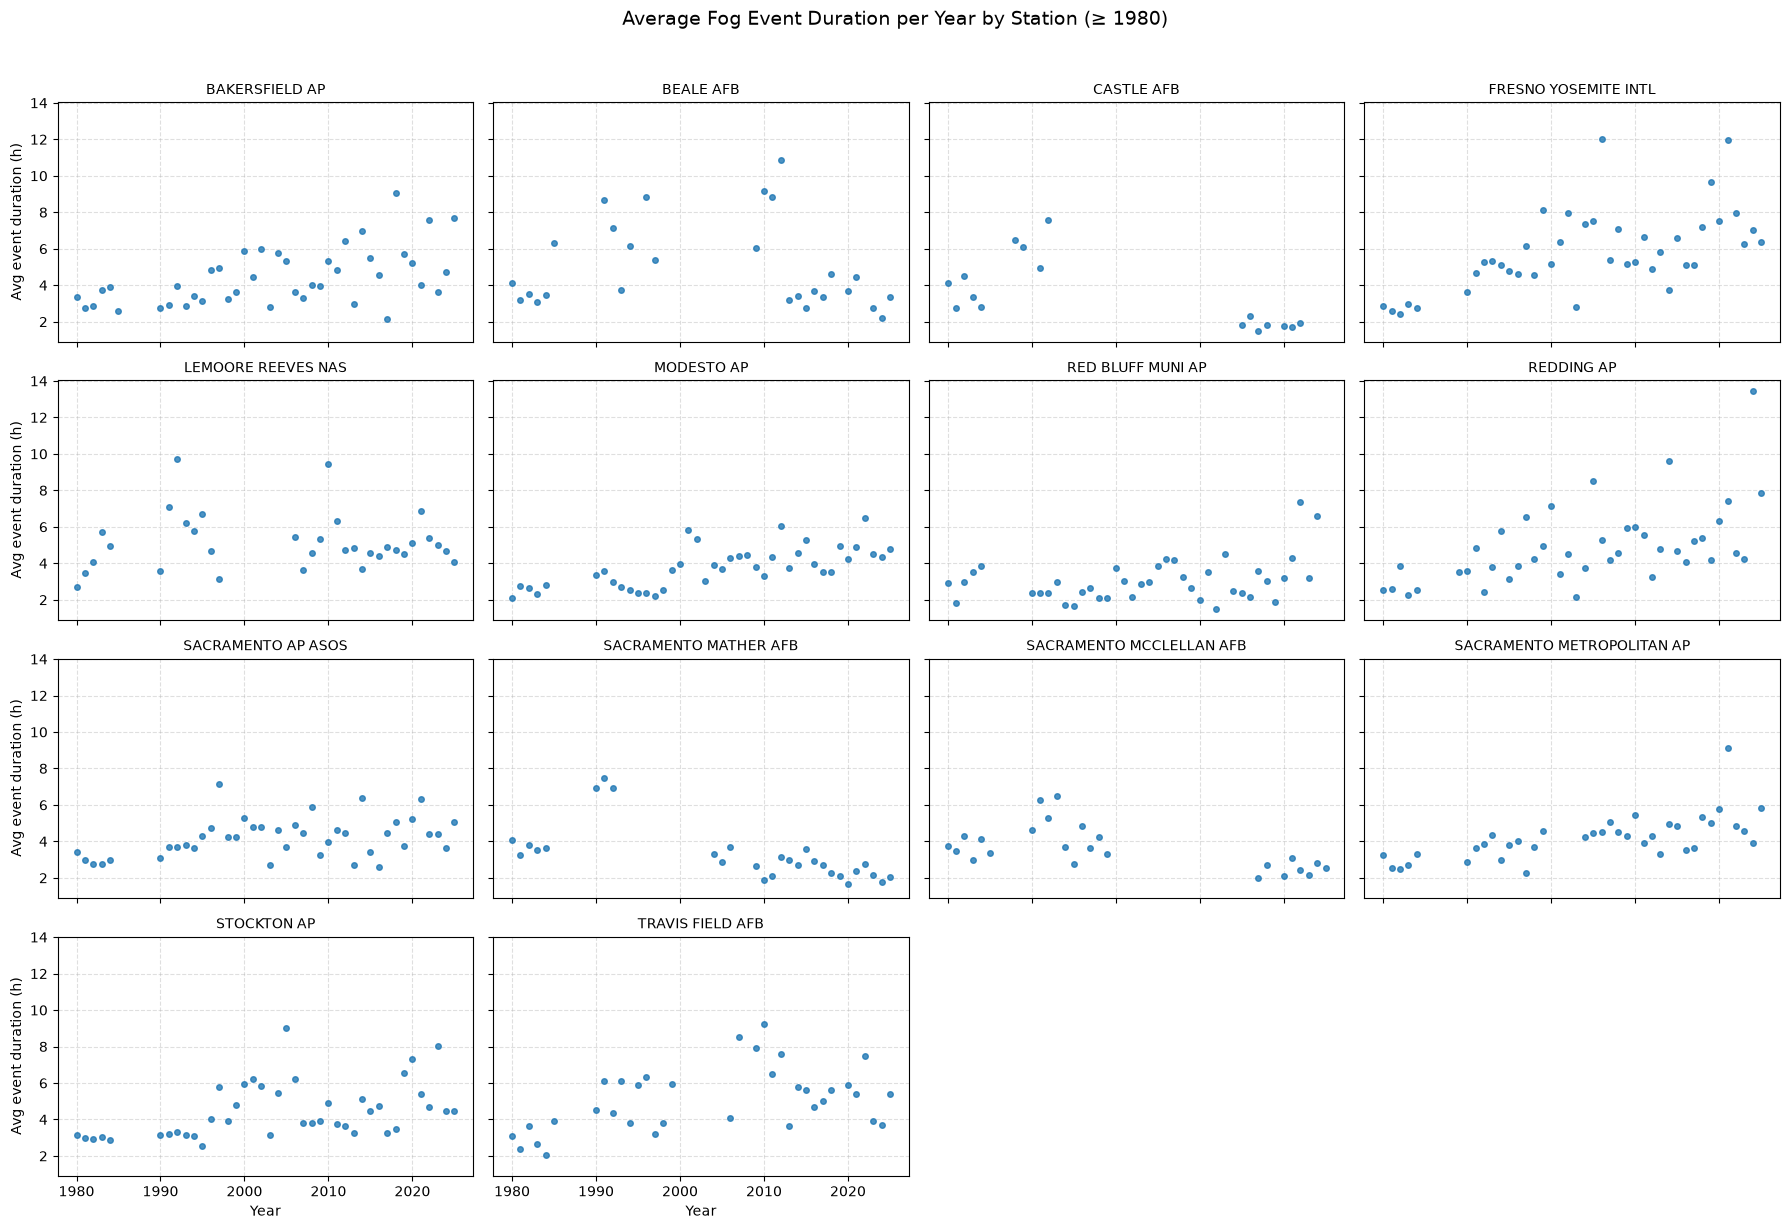

In [33]:
plot_df = annual_compare[
    (annual_compare["year"] >= 1980) &
    (annual_compare["STATION"].isin(stations_with_30_years))
].copy()

stations = plot_df["STATION"].unique().tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[
        (plot_df["STATION"] == station) &
        (plot_df["avg_event_duration_hours"].notna())
    ].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.plot(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="None",
        markersize=4,
        alpha=0.8,
        linewidth=1
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration per Year by Station (≥ 1980)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

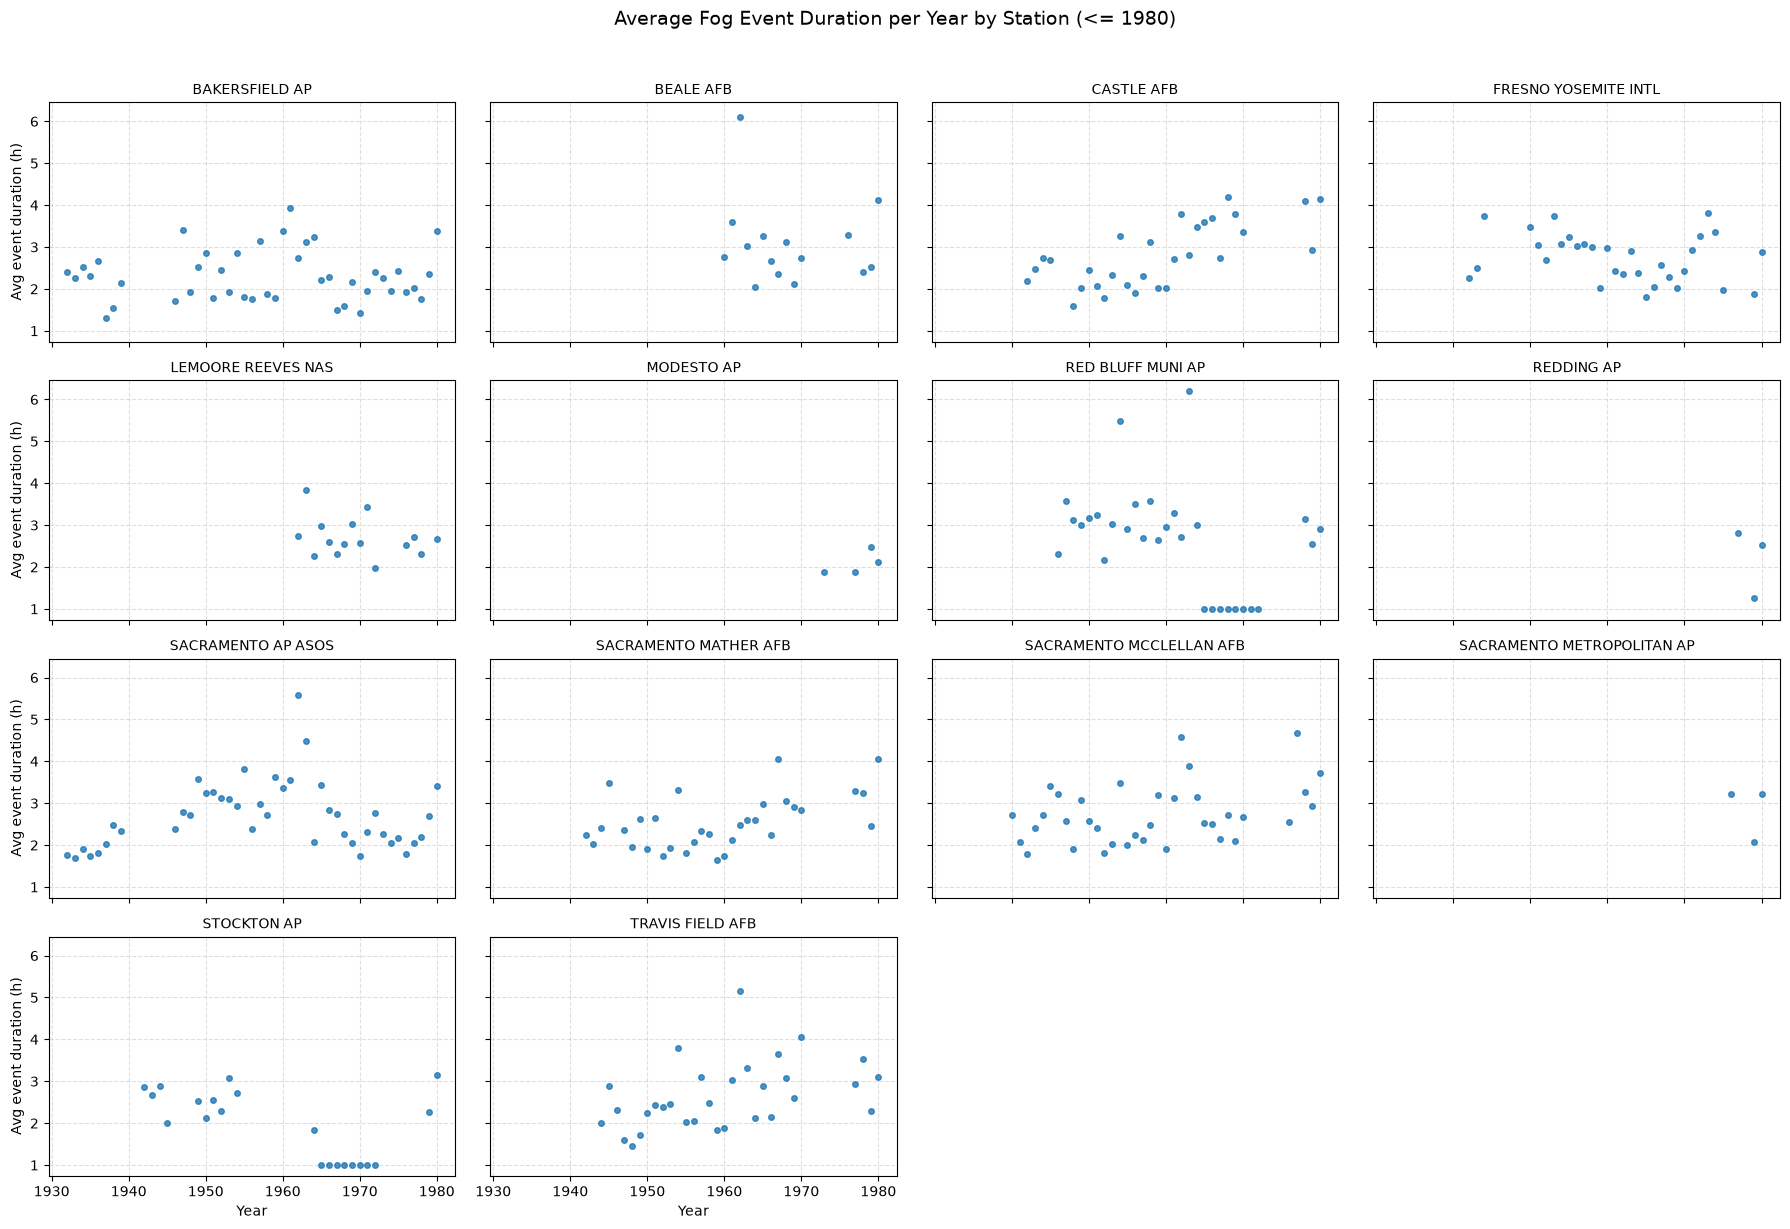

In [34]:
plot_df = annual_compare[
    (annual_compare["year"] <= 1980) &
    (annual_compare["STATION"].isin(stations_with_30_years))
].copy()

stations = plot_df["STATION"].unique().tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[
        (plot_df["STATION"] == station) &
        (plot_df["avg_event_duration_hours"].notna())
    ].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.plot(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="None",
        markersize=4,
        alpha=0.8,
        linewidth=1
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration per Year by Station (<= 1980)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

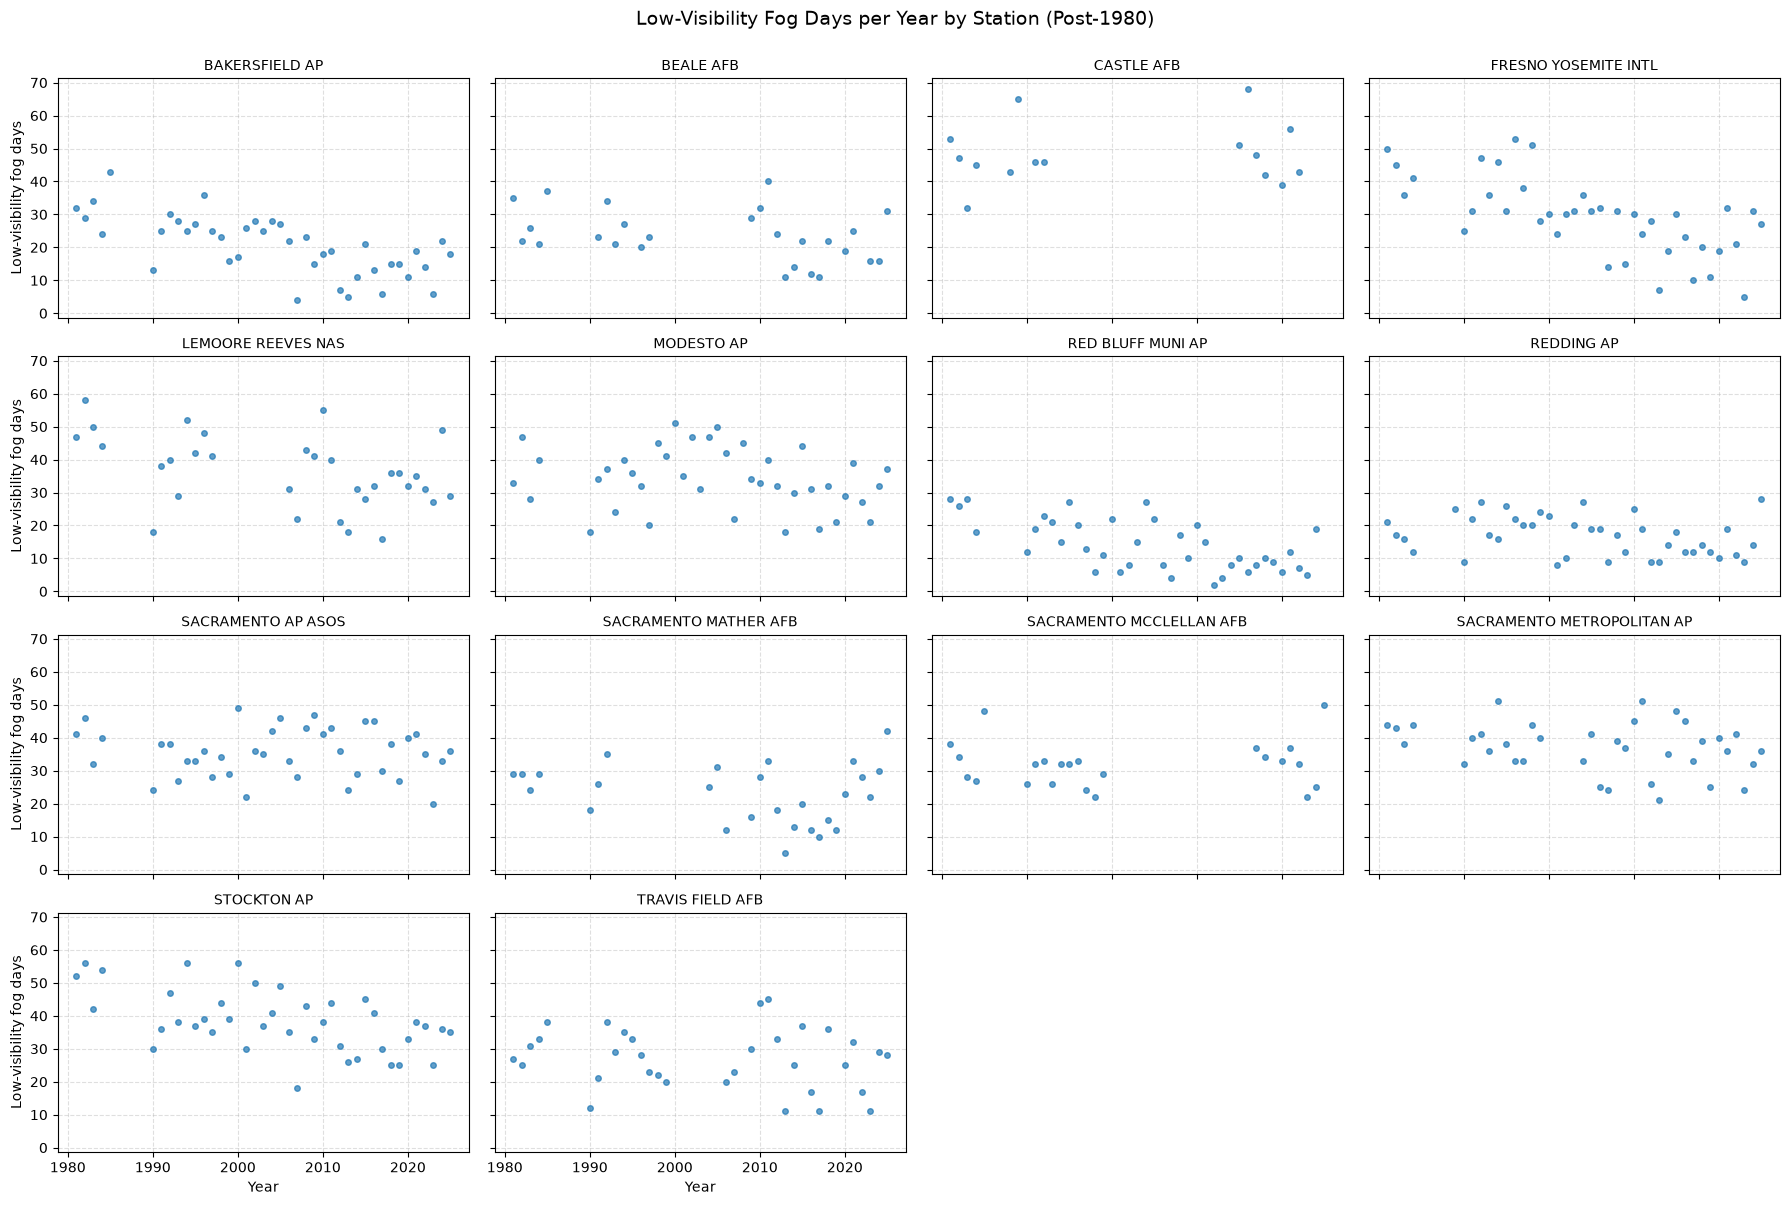

In [36]:
# Plot low-visibility fog days per year by station, only for years after 1980
stations = stations_with_30_years.tolist()
plot_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] > 1980].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.plot(
        station_df["year"],
        station_df["fog_days"],
        marker="o",
        linestyle="None",
        markersize=4,
        alpha=0.7,
        linewidth=1
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Low-visibility fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Low-Visibility Fog Days per Year by Station (Post-1980)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Pre-1980 monthly-event trends
                        STATION  n_obs  min_year  max_year     slope  \
6             RED BLUFF MUNI AP    123      1946      1979  0.095180   
5            LEMOORE REEVES NAS     79      1962      1978 -0.166295   
11             TRAVIS FIELD AFB    154      1944      1979  0.053614   
10                  STOCKTON AP    121      1942      1979 -0.035702   
8         SACRAMENTO MATHER AFB    174      1942      1979 -0.020752   
2                    CASTLE AFB    175      1942      1979 -0.018577   
4          FRESNO YOSEMITE INTL    184      1942      1979  0.016343   
9      SACRAMENTO MCCLELLAN AFB    204      1940      1979 -0.013633   
3   FRESNO CHANDLER DOWNTOWN AP     54      1934      1948 -0.046155   
0                BAKERSFIELD AP    191      1932      1979  0.003937   
7            SACRAMENTO AP ASOS    270      1932      1979 -0.103184   
1                     BEALE AFB     70      1960      1979 -0.299129   

    slope_se   p_value  r_squared

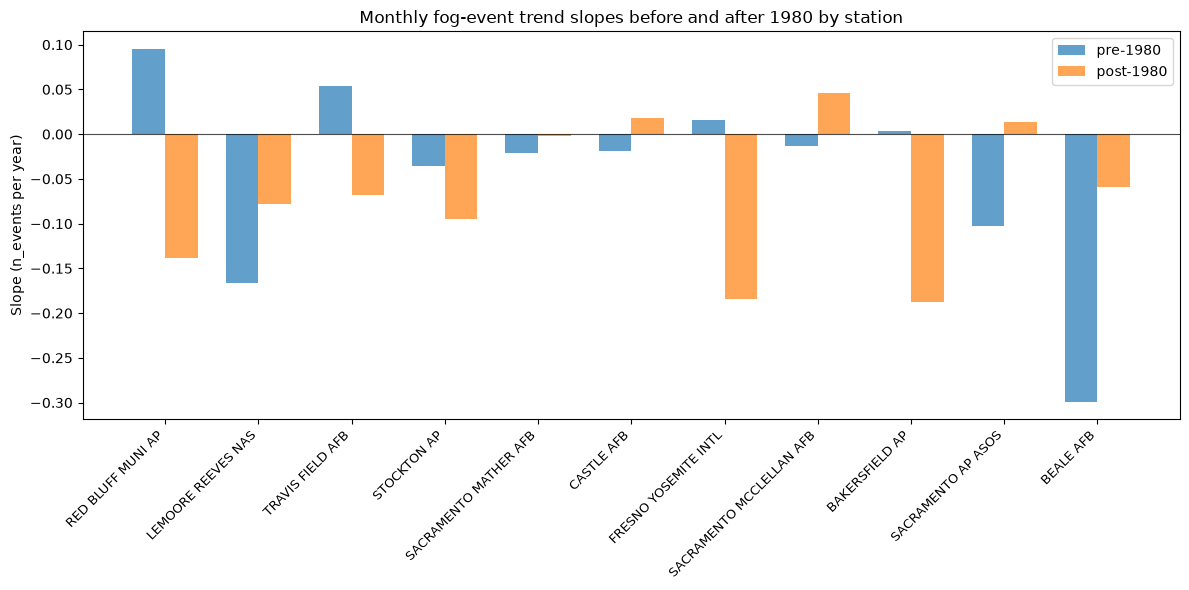

In [37]:
events_monthly = event_monthly.copy()
events_monthly["year"] = events_monthly["year"].astype(int)

def compute_station_monthly_trends(df, min_records=36):
    rows = []
    for station, g in df.groupby("STATION"):
        g = g.sort_values("year_month")
        if len(g) < min_records:
            continue
        model = smf.ols("n_events ~ year + C(month)", data=g).fit()
        rows.append({
            "STATION": station,
            "n_obs": len(g),
            "min_year": int(g["year"].min()),
            "max_year": int(g["year"].max()),
            "slope": model.params.get("year", np.nan),
            "slope_se": model.bse.get("year", np.nan),
            "p_value": model.pvalues.get("year", np.nan),
            "r_squared": model.rsquared,
            "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
        })
    return pd.DataFrame(rows).sort_values(["trend_significant", "p_value"])

events_pre1980 = events_monthly[events_monthly["year"] < 1980]
events_post1980 = events_monthly[events_monthly["year"] >= 1980]

trend_pre1980 = compute_station_monthly_trends(events_pre1980)
trend_post1980 = compute_station_monthly_trends(events_post1980)

trend_compare = (
    trend_pre1980.set_index("STATION")
    .join(trend_post1980.set_index("STATION"), lsuffix="_pre", rsuffix="_post", how="inner")
    .reset_index()
)
trend_compare["slope_change"] = trend_compare["slope_post"] - trend_compare["slope_pre"]
trend_compare["slope_change_pct"] = np.where(
    trend_compare["slope_pre"].ne(0),
    100 * trend_compare["slope_change"] / trend_compare["slope_pre"].abs(),
    np.nan,
)

print("Pre-1980 monthly-event trends")
print(trend_pre1980[["STATION","n_obs","min_year","max_year","slope","slope_se","p_value","r_squared","trend_significant"]].head(20))
print(f"\nPre-1980 stations with significant trends: {trend_pre1980['trend_significant'].sum()}/{len(trend_pre1980)}")

print("\nPost-1980 monthly-event trends")
print(trend_post1980[["STATION","n_obs","min_year","max_year","slope","slope_se","p_value","r_squared","trend_significant"]].head(20))
print(f"\nPost-1980 stations with significant trends: {trend_post1980['trend_significant'].sum()}/{len(trend_post1980)}")

print(f"\nStations with both pre-1980 and post-1980 trend estimates: {len(trend_compare)}")
display_cols = [
    "STATION",
    "slope_pre",
    "p_value_pre",
    "trend_significant_pre",
    "slope_post",
    "p_value_post",
    "trend_significant_post",
    "slope_change",
    "slope_change_pct",
]
print(trend_compare[display_cols].sort_values("p_value_post").reset_index(drop=True))

common_stations = trend_compare["STATION"].tolist()
if common_stations:
    fig, ax = plt.subplots(figsize=(max(12, len(common_stations) * 0.7), 6))
    x = np.arange(len(common_stations))
    width = 0.35

    ax.bar(x - width / 2, trend_compare["slope_pre"], width, label="pre-1980", alpha=0.7)
    ax.bar(x + width / 2, trend_compare["slope_post"], width, label="post-1980", alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(common_stations, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Slope (n_events per year)")
    ax.set_title("Monthly fog-event trend slopes before and after 1980 by station")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [38]:
station_years_no_outliers = fog_days_year_no_outliers[["STATION", "year"]].drop_duplicates()

low_vis_fog_days_year_no_outliers = low_vis_fog_days_year.merge(
    station_years_no_outliers, on=["STATION", "year"], how="inner"
)

event_monthly_no_outliers = event_monthly.merge(
    station_years_no_outliers, on=["STATION", "year"], how="inner"
)

annual_compare_no_outliers = annual_compare.merge(
    station_years_no_outliers, on=["STATION", "year"], how="inner"
)

station_year_counts_no_outliers = low_vis_fog_days_year_no_outliers.groupby("STATION")["year"].nunique()
stations_with_30_years_no_outliers = station_year_counts_no_outliers[
    station_year_counts_no_outliers >= 30
].index.tolist()

print("Filtered station-years:", station_years_no_outliers.shape[0])
print("low_vis_fog_days_year_no_outliers:", low_vis_fog_days_year_no_outliers.shape)
print("event_monthly_no_outliers:", event_monthly_no_outliers.shape)
print("annual_compare_no_outliers:", annual_compare_no_outliers.shape)
print("Stations with >= 30 years:", len(stations_with_30_years_no_outliers))

trend_stats_events_monthly_no_outliers = []
for station, df in event_monthly_no_outliers.groupby("STATION"):
    df = df.sort_values("year_month")
    if len(df) < 36:
        continue
    model = smf.ols("n_events ~ year + C(month)", data=df).fit()
    trend_stats_events_monthly_no_outliers.append({
        "STATION": station,
        "n_obs": len(df),
        "min_year": int(df["year"].min()),
        "max_year": int(df["year"].max()),
        "slope": model.params.get("year", np.nan),
        "slope_se": model.bse.get("year", np.nan),
        "p_value": model.pvalues.get("year", np.nan),
        "r_squared": model.rsquared,
        "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
    })

trend_stats_events_monthly_no_outliers = pd.DataFrame(trend_stats_events_monthly_no_outliers).sort_values("p_value")

print("\nMonthly-event trend statistics by station (restricted years):")
print(trend_stats_events_monthly_no_outliers.head(20))

significant_events_monthly_no_outliers = trend_stats_events_monthly_no_outliers[
    trend_stats_events_monthly_no_outliers["trend_significant"]
]
print(f"\nStations with significant monthly-event trends (restricted years): {len(significant_events_monthly_no_outliers)}")
print(significant_events_monthly_no_outliers[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

events_post1980_no_outliers = event_monthly_no_outliers[event_monthly_no_outliers["year"] >= 1980].copy()
events_pre1980_no_outliers = event_monthly_no_outliers[event_monthly_no_outliers["year"] < 1980].copy()

def compute_trends(df):
    stats = []
    for station, g in df.groupby("STATION"):
        g = g.sort_values("year_month")
        if len(g) < 36:
            continue
        model = smf.ols("n_events ~ year + C(month)", data=g).fit()
        stats.append({
            "STATION": station,
            "n_obs": len(g),
            "min_year": int(g["year"].min()),
            "max_year": int(g["year"].max()),
            "slope": model.params.get("year", np.nan),
            "slope_se": model.bse.get("year", np.nan),
            "p_value": model.pvalues.get("year", np.nan),
            "r_squared": model.rsquared,
            "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
        })
    return pd.DataFrame(stats).sort_values("p_value")

trend_events_post1980_no_outliers = compute_trends(events_post1980_no_outliers)
trend_events_pre1980_no_outliers = compute_trends(events_pre1980_no_outliers)

print("\nPost-1980 monthly-event trends (restricted years, top 20):")
print(trend_events_post1980_no_outliers.head(20)[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

print("\nPre-1980 monthly-event trends (restricted years, top 20):")
print(trend_events_pre1980_no_outliers.head(20)[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

annual_events_no_outliers = event_monthly_no_outliers.groupby(
    ["STATION", "year"], as_index=False
)["n_events"].sum().rename(columns={"n_events": "annual_n_events"})
print("\nAnnual events (restricted years, sample):")
print(annual_events_no_outliers.head())


Filtered station-years: 1005
low_vis_fog_days_year_no_outliers: (1004, 3)
event_monthly_no_outliers: (5288, 7)
annual_compare_no_outliers: (1004, 6)
Stations with >= 30 years: 14

Monthly-event trend statistics by station (restricted years):
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
5         FRESNO YOSEMITE INTL    385      1942      2025 -0.081736  0.012112   
7           LEMOORE REEVES NAS    247      1962      2025 -0.104794  0.019062   
14           RED BLUFF MUNI AP    280      1946      2024 -0.057145  0.014138   
6         HANFORD MUNICIPAL AP    135      2005      2025 -0.378509  0.105121   
19  SACRAMENTO METROPOLITAN AP    244      1976      2025 -0.085642  0.025471   
10   MARYSVILLE AIRPORT (ASOS)    105      2005      2025 -0.313305  0.095624   
21            TRAVIS FIELD AFB    322      1944      2025 -0.040632  0.014198   
16          SACRAMENTO AP ASOS    502      1932      2025 -0.026877  0.009663   
17       SACRAMENTO MATHER AF

Monthly-event trend statistics by station (n_events ~ year + month):
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
5         FRESNO YOSEMITE INTL    385      1942      2025 -0.081736  0.012112   
7           LEMOORE REEVES NAS    247      1962      2025 -0.104794  0.019062   
14           RED BLUFF MUNI AP    280      1946      2024 -0.057145  0.014138   
6         HANFORD MUNICIPAL AP    135      2005      2025 -0.378509  0.105121   
19  SACRAMENTO METROPOLITAN AP    244      1976      2025 -0.085642  0.025471   
10   MARYSVILLE AIRPORT (ASOS)    105      2005      2025 -0.313305  0.095624   
21            TRAVIS FIELD AFB    322      1944      2025 -0.040632  0.014198   
16          SACRAMENTO AP ASOS    502      1932      2025 -0.026877  0.009663   
17       SACRAMENTO MATHER AFB    314      1942      2025 -0.030030  0.011656   
0               BAKERSFIELD AP    366      1932      2025 -0.029752  0.012621   
20                 STOCKTON AP    355   

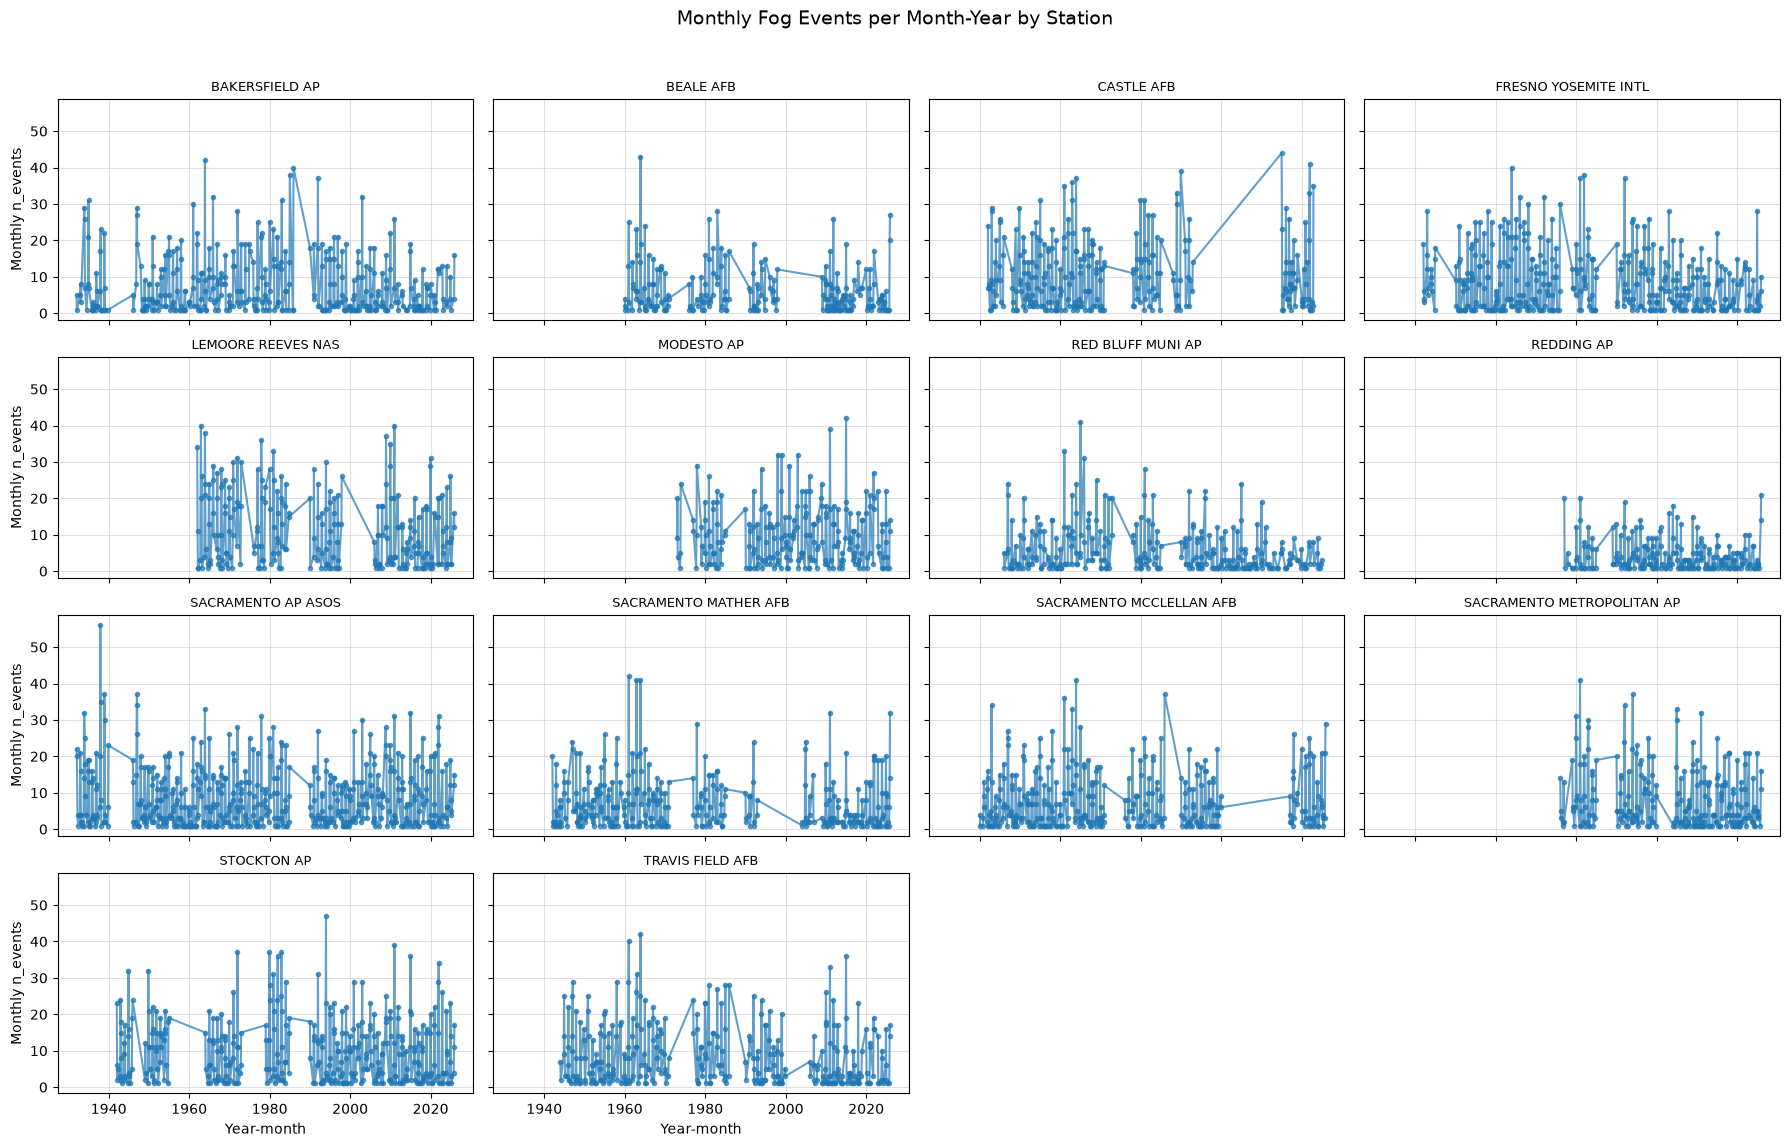

In [39]:
# Monthly-event analysis: trends of fog events per month-year by station

# use existing event_monthly (has n_events, avg_event_duration_hours, year, month, year_month)
events_monthly = event_monthly.copy()
events_monthly["year"] = events_monthly["year"].astype(int)

# station-level trends (model n_events ~ year + C(month) to account for seasonality)
trend_stats_events_monthly = []
for station, df in events_monthly.groupby("STATION"):
    df = df.sort_values("year_month")
    if len(df) < 36:  # require at least 3 years of monthly data
        continue
    model = smf.ols("n_events ~ year + C(month)", data=df).fit()
    trend_stats_events_monthly.append({
        "STATION": station,
        "n_obs": len(df),
        "min_year": df["year"].min(),
        "max_year": df["year"].max(),
        "slope": model.params.get("year", np.nan),
        "slope_se": model.bse.get("year", np.nan),
        "p_value": model.pvalues.get("year", np.nan),
        "r_squared": model.rsquared,
        "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
    })

trend_stats_events_monthly = pd.DataFrame(trend_stats_events_monthly).sort_values("p_value")
print("Monthly-event trend statistics by station (n_events ~ year + month):")
print(trend_stats_events_monthly.head(20))

significant_events_monthly = trend_stats_events_monthly[trend_stats_events_monthly["trend_significant"]]
print(f"\nStations with significant monthly-event trends: {len(significant_events_monthly)}")
print(significant_events_monthly[["STATION","n_obs","slope","p_value","r_squared"]])

# Post-1980 and Pre-1980 splits
events_post1980 = events_monthly[events_monthly["year"] >= 1980].copy()
events_pre1980 = events_monthly[events_monthly["year"] < 1980].copy()

def compute_trends(df):
    stats = []
    for station, g in df.groupby("STATION"):
        g = g.sort_values("year_month")
        if len(g) < 36:
            continue
        model = smf.ols("n_events ~ year + C(month)", data=g).fit()
        stats.append({
            "STATION": station,
            "n_obs": len(g),
            "min_year": g["year"].min(),
            "max_year": g["year"].max(),
            "slope": model.params.get("year", np.nan),
            "slope_se": model.bse.get("year", np.nan),
            "p_value": model.pvalues.get("year", np.nan),
            "r_squared": model.rsquared,
            "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
        })
    return pd.DataFrame(stats).sort_values("p_value")

trend_events_post1980 = compute_trends(events_post1980)
trend_events_pre1980 = compute_trends(events_pre1980)

print("\nPost-1980 monthly-event trends (top 20):")
print(trend_events_post1980.head(20)[["STATION","n_obs","slope","p_value","r_squared"]])

print("\nPre-1980 monthly-event trends (top 20):")
print(trend_events_pre1980.head(20)[["STATION","n_obs","slope","p_value","r_squared"]])

# Aggregate annual-seasonal diagnostics:
# annual sum of monthly events per station-year
annual_events = events_monthly.groupby(["STATION","year"], as_index=False)["n_events"].sum().rename(columns={"n_events":"annual_n_events"})
print("\nAnnual events (sample):")
print(annual_events.head())

# Plot: time series of monthly event counts for stations_with_30_years
plot_stations = stations_with_30_years.tolist()
n_stations = len(plot_stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(plot_stations):
    ax = axes[idx]
    sdf = events_monthly[events_monthly["STATION"] == station].sort_values("year_month")
    if sdf.empty:
        ax.set_visible(False)
        continue
    ax.plot(sdf["year_month"], sdf["n_events"], marker='o', linestyle='-', markersize=3, alpha=0.7)
    ax.set_title(station, fontsize=9)
    ax.grid(True, alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Monthly n_events")
    if idx >= (nrows-1)*ncols:
        ax.set_xlabel("Year-month")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Monthly Fog Events per Month-Year by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

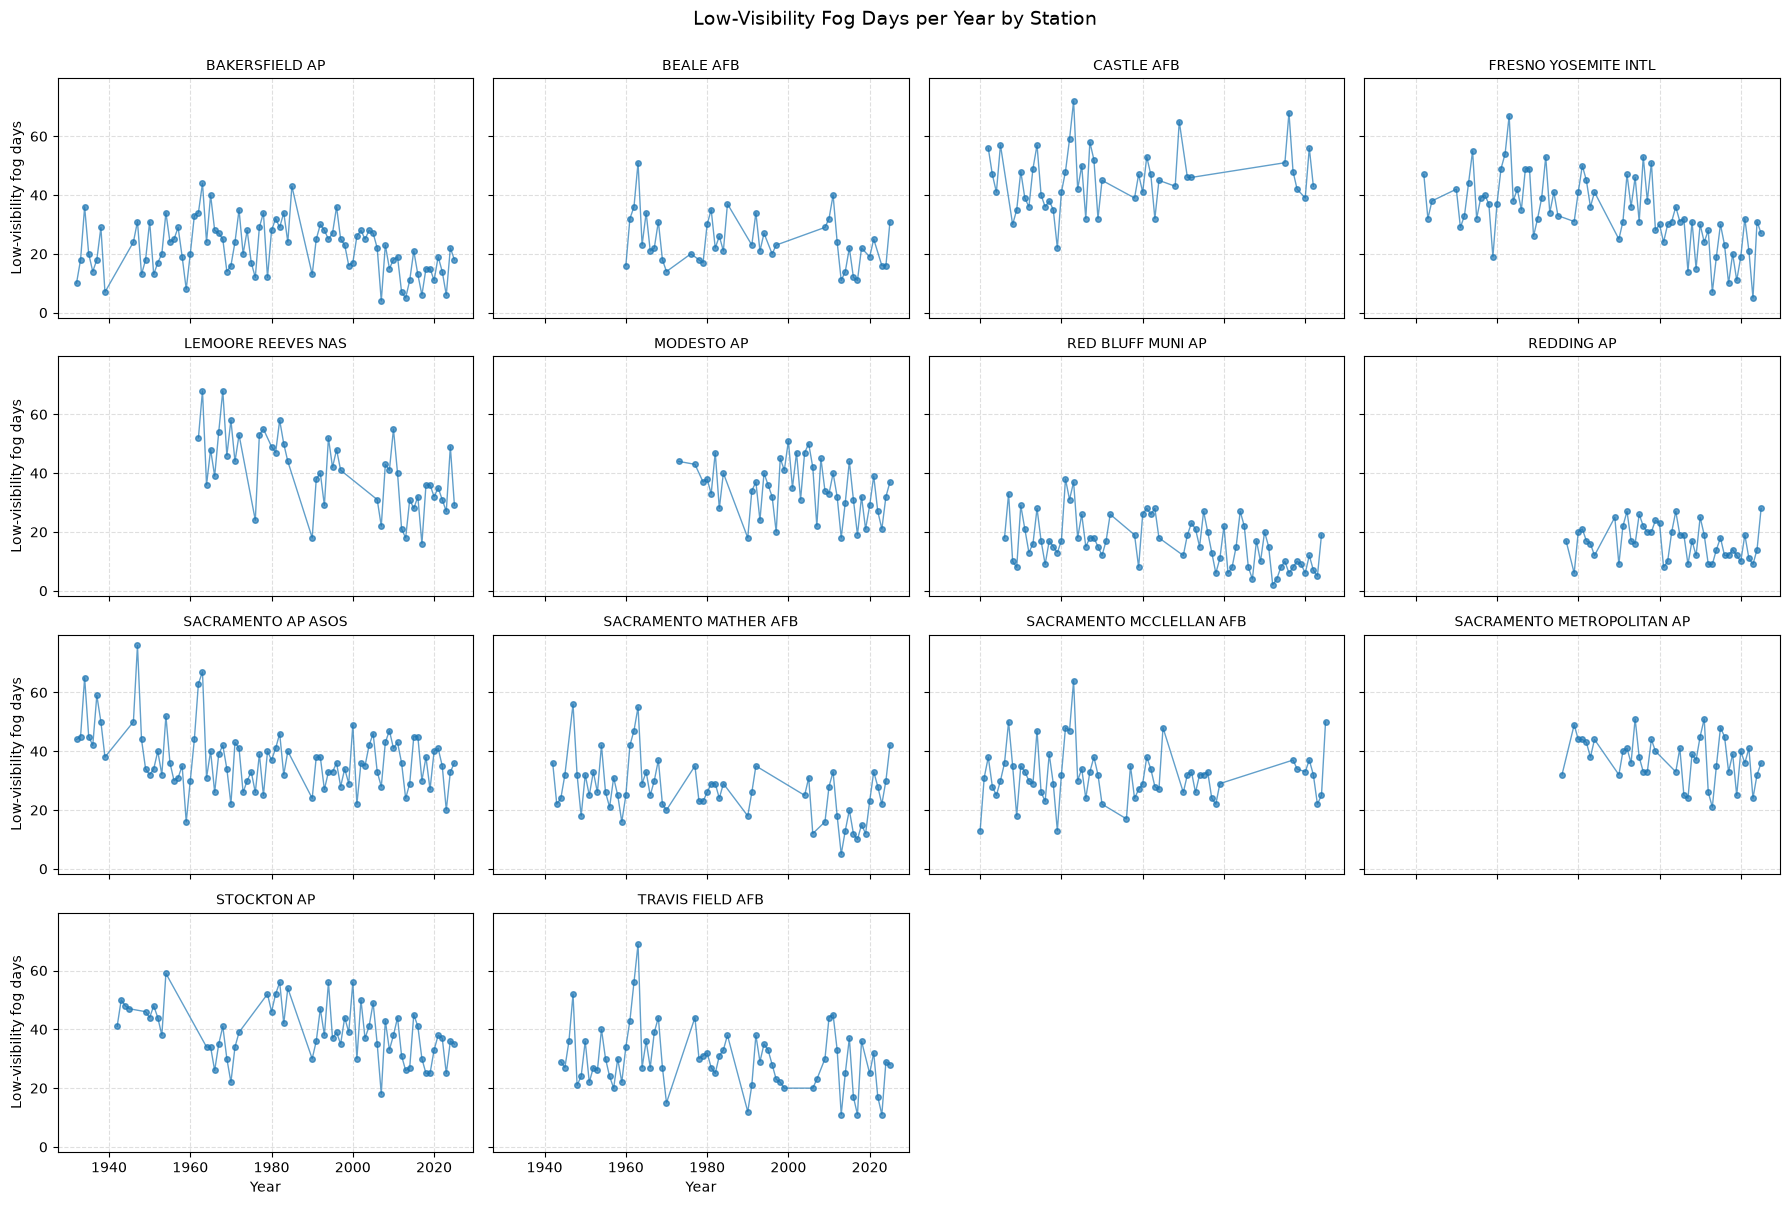

In [40]:
# Create a comprehensive plot of low-visibility fog days per station per year
stations = stations_with_30_years.tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station].sort_values('year')
    ax.plot(station_df['year'], station_df['fog_days'], marker='o', linestyle='-', markersize=4, alpha=0.7, linewidth=1)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel('Low-visibility fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low-Visibility Fog Days per Year by Station', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()